(sec:raman-tutorial)=
# Raman spectroscopy

The Raman scattering process involves the inelasic scattering of light in the visible range, leaving the molecule in a different vibrational state. The associated scattering amplitude is related to the transition polarizability tensor $\boldsymbol{\alpha}$, as discussed in more details [here](#sec:dipole-moment-grad). In the case of normal Raman scattering described using the harmonic approximation for molecular vibrations, the transition polarizability associated to a normal mode $k$ depends on the derivative of the electronic polarizability with respect to the normal coordinate $Q_k$. As a consequence, only modes along which the polarizability changes will be Raman active.

## Spectrum calculation

Here, we will calculate the Raman spectra of H$_2$O, NH$_3$ and CH$_4$ and determine how going from O over N to C influences the vibrational frequencies of the Hydrogen stretching modes.

In [1]:
import veloxchem as vlx
import py3Dmol as p3d
from veloxchem.veloxchemlib import bohr_in_angstroms

from matplotlib import pyplot as plt
import numpy as np

In [2]:
basis_set_label = '6-31G'

To compute a meaningful Raman spectrum, the molecular geometries must be optimized at the same level of theory and using the same basis set. Let us assume that we have optimized the geometries at the HF/6-31G theory level and we have these geometries stored in xyz files. Otherwise, we would start by performing the necessary geometry optimizations.

In [3]:
# Prepare molecules and basis sets

# Read optimized geometry from file
h2o_xyz = open("../../data/ir_raman/opt_h2o.xyz", "r").read()
nh3_xyz = open("../../data/ir_raman/opt_nh3.xyz", "r").read()
ch4_xyz = open("../../data/ir_raman/opt_ch4.xyz", "r").read()

h2o = vlx.Molecule.read_xyz_string(h2o_xyz)
h2o_basis = vlx.MolecularBasis.read(h2o, basis_set_label, ostream=None)

nh3 = vlx.Molecule.read_xyz_string(nh3_xyz)
nh3_basis = vlx.MolecularBasis.read(nh3, basis_set_label, ostream=None)

ch4 = vlx.Molecule.read_xyz_string(ch4_xyz)
ch4_basis = vlx.MolecularBasis.read(ch4, basis_set_label, ostream=None)

In [4]:
print("\n       (a) H2O                   (b) NH3                  (c) CH4")
viewer = p3d.view(viewergrid=(1,3),width=600,height=250, linked=True)
viewer.addModel(h2o_xyz, 'xyz', viewer=(0,0))
viewer.addModel(nh3_xyz, 'xyz', viewer=(0,1))
viewer.addModel(ch4_xyz, 'xyz', viewer=(0,2))
viewer.setViewStyle({"style": "outline", "width": 0.05})
viewer.setStyle({"stick":{},"sphere": {"scale":0.25}})
viewer.show()


       (a) H2O                   (b) NH3                  (c) CH4


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

To compute the Raman spectrum, we need the vibrational frequencies and Raman activities. The frequencies are eigenvalues of the molecular Hessian, while the Raman activities are proportional to the gradient of the polarizability. The first step is to determine the Hessian matrix.

In [5]:
# Settings:
method_settings = {}

# Numerical Hessian
vib_settings = {'do_raman': 'yes', 'print_depolarization_ratio':'yes'}

# We first need to run SCF calculations:
h2o_scf_drv = vlx.ScfRestrictedDriver()
h2o_scf_drv.ostream.mute()
h2o_results = h2o_scf_drv.compute(h2o, h2o_basis)

nh3_scf_drv = vlx.ScfRestrictedDriver()
nh3_scf_drv.ostream.mute()
nh3_results = nh3_scf_drv.compute(nh3, nh3_basis)

ch4_scf_drv = vlx.ScfRestrictedDriver()
ch4_scf_drv.ostream.mute()
ch4_results = ch4_scf_drv.compute(ch4, ch4_basis)

In [6]:
# Create a Hessian driver object, update settings, and compute 
h2o_vibanalysis_drv = vlx.VibrationalAnalysis(h2o_scf_drv)
h2o_vibanalysis_drv.update_settings(method_settings, vib_settings)

nh3_vibanalysis_drv = vlx.VibrationalAnalysis(nh3_scf_drv)
nh3_vibanalysis_drv.update_settings(method_settings, vib_settings)

ch4_vibanalysis_drv = vlx.VibrationalAnalysis(ch4_scf_drv)
ch4_vibanalysis_drv.update_settings(method_settings, vib_settings)

In [8]:
# Calculate hessians from scratch
h2o_results = h2o_vibanalysis_drv.compute(h2o, h2o_basis)
nh3_results = nh3_vibanalysis_drv.compute(nh3, nh3_basis)
ch4_results = ch4_vibanalysis_drv.compute(ch4, ch4_basis)

In [9]:
def add_broadening(list_ex_energy, list_osci_strength, line_profile='Lorentzian', line_param=10, step=10):
        x_min = np.amin(list_ex_energy) - 50
        x_max = np.amax(list_ex_energy) + 50
        x = np.arange(x_min, x_max, step)
        y = np.zeros((len(x)))

        # go through the frames and calculate the spectrum for each frame
        for xp in range(len(x)):
            for e, f in zip(list_ex_energy, list_osci_strength):
                if line_profile == 'Gaussian':
                    y[xp] += f * np.exp(-(
                        (e - x[xp]) / line_param)**2)
                elif line_profile == 'Lorentzian':
                    y[xp] += 0.5 * line_param * f / (np.pi * (
                        (x[xp] - e)**2 + 0.25 * line_param**2))
        return x, y

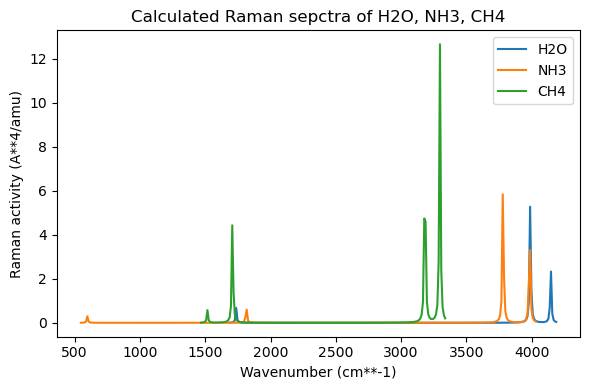

In [10]:
# plot the Raman spectra
plt.figure(figsize=(6,4))

freq = 0

h2o_x,h2o_y = h2o_vibanalysis_drv.vib_frequencies, h2o_vibanalysis_drv.raman_activities[freq]
nh3_x,nh3_y = nh3_vibanalysis_drv.vib_frequencies, nh3_vibanalysis_drv.raman_activities[freq]
ch4_x,ch4_y = ch4_vibanalysis_drv.vib_frequencies, ch4_vibanalysis_drv.raman_activities[freq]

h2o_xl, h2o_yl = add_broadening(h2o_x, h2o_y, line_profile='Lorentzian', line_param=10, step=10)
nh3_xl, nh3_yl = add_broadening(nh3_x, nh3_y, line_profile='Lorentzian', line_param=10, step=10)
ch4_xl, ch4_yl = add_broadening(ch4_x, ch4_y, line_profile='Lorentzian', line_param=10, step=10)

plt.plot(h2o_xl, h2o_yl, label='H2O')
plt.plot(nh3_xl, nh3_yl, label='NH3')
plt.plot(ch4_xl, ch4_yl, label='CH4')

plt.xlabel('Wavenumber (cm**-1)')
plt.ylabel('Raman activity (A**4/amu)')
plt.title("Calculated Raman sepctra of H2O, NH3, CH4")
plt.legend()
plt.tight_layout(); plt.show()

Let's compare the H-stretching modes:

In [11]:
# To animate the normal mode we will need both the geometry and the displacements 
def get_normal_mode(molecule, normal_mode):
    elements = molecule.get_labels()
    coords = molecule.get_coordinates_in_angstrom()
    natm = molecule.number_of_atoms()
    vib_xyz = "%d\n\n" % natm
    nm = normal_mode.reshape(natm, 3)
    
    for i in range(natm):
        # add coordinates:
        vib_xyz += elements[i] + " %15.7f %15.7f %15.7f " % (coords[i,0], coords[i,1], coords[i,2])
        # add displacements:
        vib_xyz += "%15.7f %15.7f %15.7f\n" % (nm[i,0], nm[i,1], nm[i,2])
    return vib_xyz

In [12]:
h2o_h1 = get_normal_mode(h2o, h2o_vibanalysis_drv.normal_modes[-2])
h2o_h2 = get_normal_mode(h2o, h2o_vibanalysis_drv.normal_modes[-1])

nh3_h1 = get_normal_mode(nh3, nh3_vibanalysis_drv.normal_modes[-3])
nh3_h2 = get_normal_mode(nh3, nh3_vibanalysis_drv.normal_modes[-2])
nh3_h3 = get_normal_mode(nh3, nh3_vibanalysis_drv.normal_modes[-1])

ch4_h1 = get_normal_mode(ch4, ch4_vibanalysis_drv.normal_modes[-4])
ch4_h2 = get_normal_mode(ch4, ch4_vibanalysis_drv.normal_modes[-3])
ch4_h3 = get_normal_mode(ch4, ch4_vibanalysis_drv.normal_modes[-2])
ch4_h4 = get_normal_mode(ch4, ch4_vibanalysis_drv.normal_modes[-1])

In [13]:
print("These are the two H stretching modes of H2O.")
view = p3d.view(viewergrid=(1,2), width=300, height=200, linked=True)
view.addModel(h2o_h1, "xyz", {'vibrate': {'frames':10,'amplitude':0.75}}, viewer=(0,0))
view.addModel(h2o_h2, "xyz", {'vibrate': {'frames':10,'amplitude':0.75}}, viewer=(0,1))

view.setViewStyle({"style": "outline", "width": 0.05})
view.setStyle({"stick":{},"sphere": {"scale":0.25}})
view.animate({'loop': 'backAndForth'})
view.rotate(120, "x")
view.zoomTo()
view.show()

These are the two H stretching modes of H2O.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [14]:
print("These are the three H stretching modes of NH3.")
view = p3d.view(viewergrid=(1,3), width=600, height=200, linked=True)
view.addModel(nh3_h1, "xyz", {'vibrate': {'frames':10,'amplitude':0.75}}, viewer=(0,0))
view.addModel(nh3_h2, "xyz", {'vibrate': {'frames':10,'amplitude':0.75}}, viewer=(0,1))
view.addModel(nh3_h3, "xyz", {'vibrate': {'frames':10,'amplitude':0.75}}, viewer=(0,2))

view.setViewStyle({"style": "outline", "width": 0.05})
view.setStyle({"stick":{},"sphere": {"scale":0.25}})
view.animate({'loop': 'backAndForth'})
view.rotate(90, "x")
view.zoomTo()
view.show()

These are the three H stretching modes of NH3.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [15]:
print("These are the four H stretching modes of CH4.")
view = p3d.view(viewergrid=(1,4), width=600, height=200, linked=True)
view.addModel(ch4_h1, "xyz", {'vibrate': {'frames':10,'amplitude':0.75}}, viewer=(0,0))
view.addModel(ch4_h2, "xyz", {'vibrate': {'frames':10,'amplitude':0.75}}, viewer=(0,1))
view.addModel(ch4_h3, "xyz", {'vibrate': {'frames':10,'amplitude':0.75}}, viewer=(0,2))
view.addModel(ch4_h4, "xyz", {'vibrate': {'frames':10,'amplitude':0.75}}, viewer=(0,3))

view.setViewStyle({"style": "outline", "width": 0.05})
view.setStyle({"stick":{},"sphere": {"scale":0.25}})
view.animate({'loop': 'backAndForth'})
view.zoomTo()
view.show()

These are the four H stretching modes of CH4.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.